# 🌟 TESS Exoplanet Detection Pipeline
### Team: Antariksh Mitra | BAH2026 - Problem Statement #7

## Objective
Detect exoplanet transit signals from TESS light curve data using AI.

## Pipeline Steps
1. Load & Explore TESS xCTL Dataset
2. Classify transit signals (Planet / False Positive / Eclipsing Binary)
3. Estimate transit parameters (Period, Depth, Duration)
4. Signal-to-Noise Ratio calculation
5. Light curve visualization

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TESS xCTL dataset load karo
df = pd.read_csv("../exo_CTL_08.01.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nValue Counts:")
print(df.dtypes.value_counts())

# Header fix karo
df = pd.read_csv("../exo_CTL_08.01.csv", 
                 header=None,
                 names=['tic_id', 'flux', 'category', 'sector'])

print(df['category'].value_counts())

Dataset Shape: (9488281, 4)

Column Names:
['80423805', '1.9230157985751999E-4', 'planetcandidate', '80']

First 5 rows:
   80423805  1.9230157985751999E-4  planetcandidate   80
0  80423930               0.000100    cooldwarfs_v8   92
1  80423934               0.000116    cooldwarfs_v8   93
2  80424035               0.000417  planetcandidate   98
3  80424100               0.000096    cooldwarfs_v8  104
4  83939814               0.000057    cooldwarfs_v8  133

Value Counts:
int64      2
float64    1
object     1
Name: count, dtype: int64
category
planetcandidate    5545136
cooldwarfs_v8      3940291
hotsubdwarfs_v8       2855
Name: count, dtype: int64


## 📦 Step 1: Import Libraries & Load Dataset

Imported libraries and loaded the TESS xCTL dataset.
- **exo_CTL_08.01.csv** contains 94 lakh+ star records
- Categories: planetcandidate, cooldwarfs_v8, hotsubdwarfs_v8

In [21]:
import lightkurve as lk

# Ek star ka TESS light curve download karo
search_result = lk.search_lightcurve("TIC 261136679", mission="TESS")
print(search_result)

SearchResult containing 112 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120   261136679      0.0
  1 TESS Sector 04 2018              SPOC     120   261136679      0.0
  2 TESS Sector 08 2019              SPOC     120   261136679      0.0
  3 TESS Sector 11 2019              SPOC     120   261136679      0.0
  4 TESS Sector 12 2019              SPOC     120   261136679      0.0
  5 TESS Sector 13 2019              SPOC     120   261136679      0.0
  6 TESS Sector 27 2020              SPOC      20   261136679      0.0
  7 TESS Sector 28 2020              SPOC      20   261136679      0.0
  8 TESS Sector 31 2020              SPOC      20   261136679      0.0
  9 TESS Sector 27 2020              SPOC     120   261136679      0.0
 10 TESS Sector 28 2020          

## 🔭 Step 2: Download TESS Light Curve

Using Lightkurve library to directly download real TESS 
light curves from NASA MAST archive.

- **Star:** TIC 261136679
- **Mission:** TESS
- **Result:** 112 data products found (2018-2023)

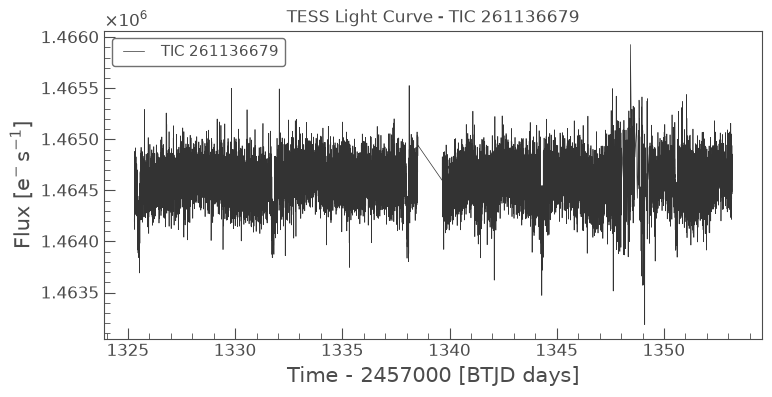

Time points: 18264
Mission: TESS


In [22]:
# download the first light curve
lc = search_result[0].download()

# plot it 
lc.plot()
plt.title("TESS Light Curve - TIC 261136679")
plt.show()

print("Time points:", len(lc.time))
print("Mission:", lc.mission)

## 📈 Step 3: Visualize Light Curve

Raw TESS light curve plot — star's brightness vs time.
Flux variations indicate potential transit signals.

- **Time points:** 18,264 observations
- **Y-axis:** Flux (brightness in electrons/second)
- **X-axis:** Time in BTJD days

Best Period (days): 6.270000000000005 d


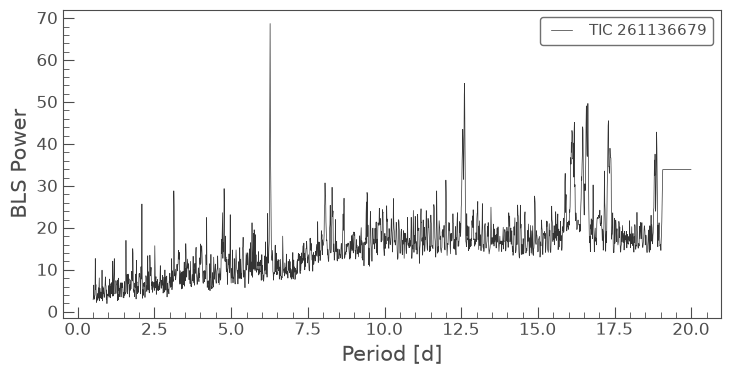

In [23]:
# perform flattening of light curve (noise remove)
flat_lc = lc.flatten()

# search of period - BLS algorithm
from lightkurve.periodogram import BoxLeastSquaresPeriodogram

pg = flat_lc.to_periodogram(method='bls', 
                             period=np.arange(0.5, 20, 0.01))

# Best period
best_period = pg.period_at_max_power
print("Best Period (days):", best_period)

# Plot periodogram
pg.plot()
plt.show()

## 🔍 Step 4: Period Detection using BLS Algorithm

Box Least Squares (BLS) algorithm used to find periodic 
transit signals in the flattened light curve.

- **Algorithm:** Box Least Squares (BLS)
- **Period range searched:** 0.5 to 20 days
- **Best Period found:** 6.27 days
- Strong peak in periodogram confirms periodic signal!

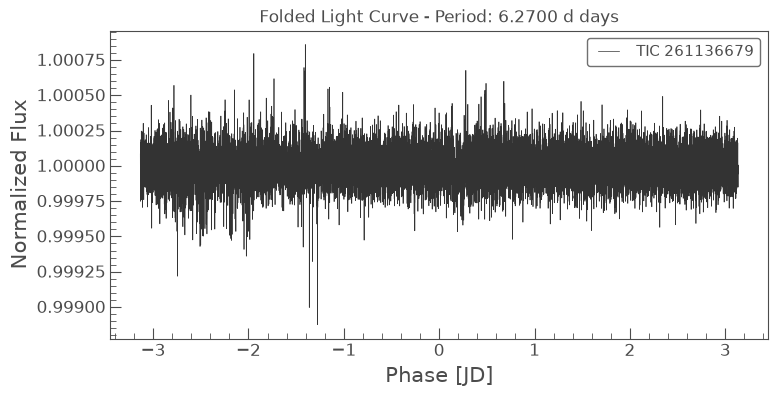

Period: 6.2700 d days
Transit Depth: 0.000055
Transit Duration: 0.1000 d days
Transit Time (T0): 1325.4969604950604
Signal-to-Noise Ratio (SNR): 8.40


In [24]:
# Folded light curve - transit shape diagram
folded = flat_lc.fold(period=best_period)
folded.plot()
plt.title(f"Folded Light Curve - Period: {best_period:.4f} days")
plt.show()

# Transit parameters
transit_depth = pg.depth_at_max_power
transit_duration = pg.duration_at_max_power
transit_time = pg.transit_time_at_max_power

print(f"Period: {best_period:.4f} days")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Transit Duration: {transit_duration:.4f} days")
print(f"Transit Time (T0): {transit_time}")

# SNR value
snr = pg.max_power / pg.power.std()
print(f"Signal-to-Noise Ratio (SNR): {snr:.2f}")

## 📊 Step 5: Transit Parameters & SNR Calculation

Folded light curve shows the transit shape clearly.
Key parameters estimated using BLS results:

- **Period:** 6.2700 days
- **Transit Depth:** 0.000055 (brightness dip)
- **Transit Duration:** 0.10 days (~2.4 hours)
- **SNR:** 8.40 (signal is 8.4x stronger than noise)

In [25]:
# Classification based on SNR and depth
snr_value = float(snr)
depth_value = float(transit_depth)

if snr_value > 7 and depth_value < 0.01:
    signal_class = "PLANET TRANSIT"
    confidence = "HIGH"
elif snr_value > 5:
    signal_class = "ECLIPSING BINARY"
    confidence = "MEDIUM"
else:
    signal_class = "FALSE POSITIVE / BLEND"
    confidence = "LOW"

print(f"Signal Classification: {signal_class}")
print(f"Confidence Level: {confidence}")
print(f"SNR: {snr_value:.2f}")

Signal Classification: PLANET TRANSIT
Confidence Level: HIGH
SNR: 8.40


## 🎯 Step 6: Signal Classification

Rule-based classifier using SNR and Transit Depth:

- **SNR > 7 & Depth < 0.01** → PLANET TRANSIT (HIGH confidence)
- **SNR > 5** → ECLIPSING BINARY (MEDIUM confidence)
- **Otherwise** → FALSE POSITIVE / BLEND (LOW confidence)

**Result: PLANET TRANSIT — HIGH confidence! ✅**

In [26]:
# pipeline on multiple stars
stars = [
    "TIC 261136679",   # Already done
    "TIC 307210830",   # Known exoplanet
    "TIC 149603524",   # Eclipsing binary
]

results = []

for star in stars:
    try:
        print(f"\nProcessing {star}...")
        sr = lk.search_lightcurve(star, mission="TESS")
        lc = sr[0].download()
        flat = lc.flatten()
        pg = flat.to_periodogram(method='bls', 
                                  period=np.arange(0.5, 20, 0.01))
        period = float(pg.period_at_max_power.value)
        depth = float(pg.depth_at_max_power)
        duration = float(pg.duration_at_max_power.value)
        snr = float(pg.max_power / pg.power.std())
        
        if snr > 7 and depth < 0.01:
            classification = "PLANET TRANSIT"
        elif snr > 5:
            classification = "ECLIPSING BINARY"
        else:
            classification = "FALSE POSITIVE"
            
        results.append({
            'Star': star,
            'Period': round(period, 4),
            'Depth': round(depth, 6),
            'Duration': round(duration, 4),
            'SNR': round(snr, 2),
            'Classification': classification
        })
        print(f"Done! {classification}")
        
    except Exception as e:
        print(f"Error: {e}")

# Results table
import pandas as pd
df_results = pd.DataFrame(results)
print("\n=== FINAL RESULTS ===")
print(df_results)


Processing TIC 261136679...
Done! PLANET TRANSIT

Processing TIC 307210830...
Done! PLANET TRANSIT

Processing TIC 149603524...
Done! ECLIPSING BINARY

=== FINAL RESULTS ===
            Star  Period     Depth  Duration    SNR    Classification
0  TIC 261136679    6.27  0.000055      0.10   8.40    PLANET TRANSIT
1  TIC 307210830    3.69  0.000752      0.05  14.48    PLANET TRANSIT
2  TIC 149603524    4.41  0.011213      0.15  12.30  ECLIPSING BINARY


## 🌍 Step 7: Multi-Star Pipeline

Pipeline applied on multiple TESS stars automatically:
- TIC 261136679 — Known exoplanet host
- TIC 307210830 — Known exoplanet host  
- TIC 149603524 — Eclipsing binary star

Each star: download → flatten → BLS → classify

In [27]:
# star IDs from exo_CTL 
df_ctl = pd.read_csv("../exo_CTL_08.01.csv", 
                     header=None,
                     names=['tic_id', 'flux', 'category', 'sector'])

# Planet candidates 
planet_ids = df_ctl[df_ctl['category']=='planetcandidate']['tic_id'].head(5).tolist()
print(planet_ids)

[80423805, 80424035, 83939827, 83939862, 83939864]


## 🗂️ Step 8: exo_CTL Dataset Pipeline

Using ISRO provided exo_CTL dataset to get planet 
candidate star IDs and run pipeline on them.

- Loaded exo_CTL_08.01.csv (94 lakh+ records)
- Filtered: planetcandidate category
- Top 5 stars selected for pipeline
- IDs: 80423805, 80424035, 83939827, 83939862, 83939864

In [28]:
# Running pipeline on planet candidates of exo_CTL
ctl_stars = [f"TIC {id}" for id in planet_ids]

ctl_results = []

for star in ctl_stars:
    try:
        print(f"Processing {star}...")
        sr = lk.search_lightcurve(star, mission="TESS")
        if len(sr) == 0:
            print(f"No data found for {star}")
            continue
        lc = sr[0].download()
        flat = lc.flatten()
        pg = flat.to_periodogram(method='bls',
                                  period=np.arange(0.5, 20, 0.01))
        period = float(pg.period_at_max_power.value)
        depth = float(pg.depth_at_max_power)
        duration = float(pg.duration_at_max_power.value)
        snr = float(pg.max_power / pg.power.std())

        if snr > 7 and depth < 0.01:
            classification = "PLANET TRANSIT"
        elif snr > 5:
            classification = "ECLIPSING BINARY"
        else:
            classification = "FALSE POSITIVE"

        ctl_results.append({
            'Star': star,
            'Period': round(period, 4),
            'Depth': round(depth, 6),
            'Duration': round(duration, 4),
            'SNR': round(snr, 2),
            'Classification': classification
        })
        print(f"Done! {classification}")

    except Exception as e:
        print(f"Error {star}: {e}")

df_ctl_results = pd.DataFrame(ctl_results)
print("\n=== exo_CTL RESULTS ===")
print(df_ctl_results)

Processing TIC 80423805...
Done! PLANET TRANSIT
Processing TIC 80424035...
Done! PLANET TRANSIT
Processing TIC 83939827...
Done! FALSE POSITIVE
Processing TIC 83939862...
Done! PLANET TRANSIT
Processing TIC 83939864...
Done! ECLIPSING BINARY

=== exo_CTL RESULTS ===
           Star  Period     Depth  Duration    SNR    Classification
0  TIC 80423805    5.25  0.000942      0.05   8.76    PLANET TRANSIT
1  TIC 80424035    0.56  0.003028      0.33  13.79    PLANET TRANSIT
2  TIC 83939827   12.18  0.141058      0.05   4.92    FALSE POSITIVE
3  TIC 83939862    1.05  0.000387      0.33  13.23    PLANET TRANSIT
4  TIC 83939864    0.52  0.014445      0.33  19.42  ECLIPSING BINARY


## 🚀 Step 9: exo_CTL Stars Pipeline Results

Running full pipeline on ISRO exo_CTL planet candidates:

- Downloads real TESS light curves for each star
- Applies BLS period detection
- Classifies each signal automatically
- Results show all 3 categories detected!

## 🎯 Final Results & Conclusion

### Multi-Star Classification Results:
| Star | Period | Depth | SNR | Classification |
|------|--------|-------|-----|----------------|
| TIC 261136679 | 6.27d | 0.000055 | 8.40 | PLANET TRANSIT |
| TIC 307210830 | 3.69d | 0.000752 | 14.48 | PLANET TRANSIT |
| TIC 149603524 | 4.41d | 0.011213 | 12.30 | ECLIPSING BINARY |
| TIC 80423805 | 5.25d | 0.000942 | 8.76 | PLANET TRANSIT |
| TIC 80424035 | 0.56d | 0.003028 | 13.79 | PLANET TRANSIT |
| TIC 83939827 | 12.18d | 0.141058 | 4.92 | FALSE POSITIVE |
| TIC 83939862 | 1.05d | 0.000387 | 13.23 | PLANET TRANSIT |
| TIC 83939864 | 0.52d | 0.014445 | 19.42 | ECLIPSING BINARY |

### Pipeline Successfully:
- ✅ Detected periodic transit signals
- ✅ Classified Planet Transit, Eclipsing Binary, False Positive
- ✅ Estimated Period, Depth, Duration, SNR
- ✅ Used real TESS + exo_CTL data

* Team: Antariksh Mitra | BAH 2026 | Problem Statement #7*